# 📘 Aula 1 — Representações Conceituais de Palavras
### Curso de Processamento de Linguagem Natural

---

## 🎯 Objetivos desta aula

Ao final desta aula, você será capaz de:

- Entender **o que são ontologias** e por que elas importam para computadores
- Compreender o conceito de **grafos de conhecimento**
- Usar a biblioteca **WordNet** para explorar o significado das palavras
- Conhecer o **BabelNet** como recurso multilíngue
- Visualizar relações entre palavras usando **grafos**

---

## 📚 Embasamento Teórico

### 1.1 — O problema: como o computador entende palavras?

Quando você lê a palavra **"banco"**, seu cérebro automaticamente entende o contexto:

- *"Sentei no **banco** da praça"* → móvel para sentar
- *"Fui ao **banco** sacar dinheiro"* → instituição financeira

Para um computador, a palavra **"banco"** é apenas uma sequência de letras.  
**Como ensinamos o computador a entender o significado?**  
A resposta está nas **ontologias** e nos **grafos de conhecimento**.

---

### 1.2 — O que é uma Ontologia?

Uma **ontologia** é uma estrutura formal que organiza conceitos e as relações entre eles.  
Pense nela como um **dicionário inteligente** que não apenas define palavras, mas também diz:

- O que uma coisa **É** (definição)
- Do que ela **FAZ PARTE** (composição)
- Como ela se **RELACIONA** com outras coisas

**Exemplo simples:**
```
Cachorro
  ├── É um: Animal
  ├── É um: Mamífero
  ├── Tem partes: pata, rabo, focinho
  └── É relacionado a: gato, lobo, raposa
```

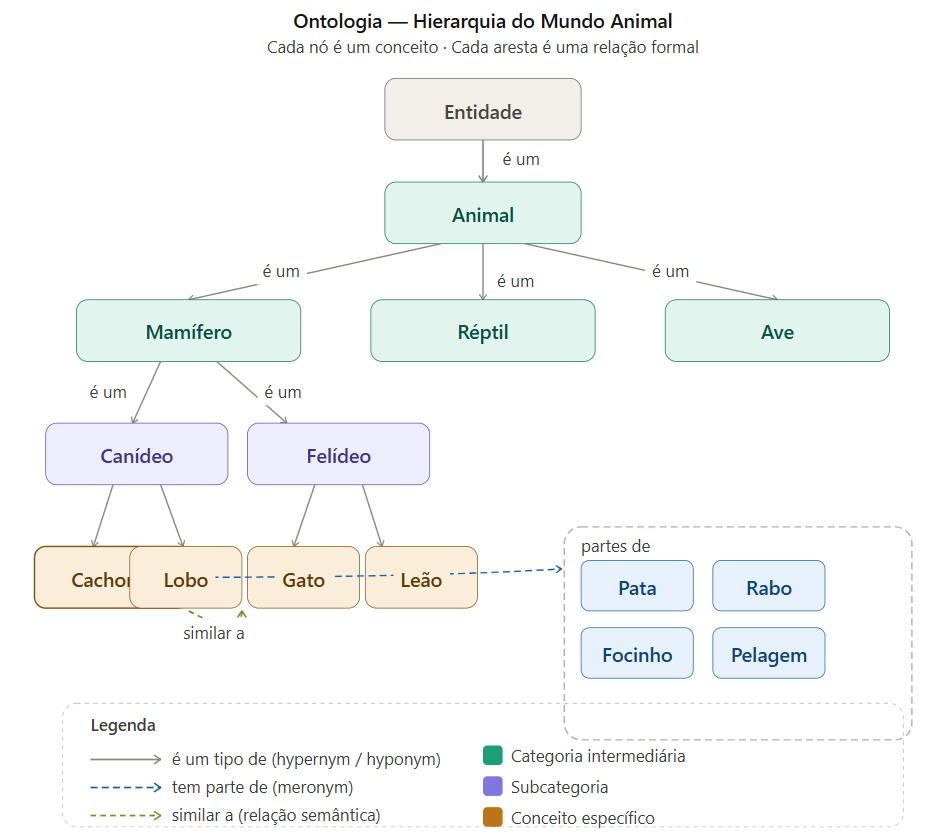

---

### 1.3 — O que é um Grafo de Conhecimento?

Um **grafo de conhecimento** é uma forma de representar ontologias visualmente,  
usando **nós** (conceitos) e **arestas** (relações).

```
  [Animal] ──é um──> [Mamífero] ──é um──> [Cachorro]
                                               │
                                          relacionado
                                               │
                                            [Lobo]
```

Exemplos famosos de grafos de conhecimento:
- **Google Knowledge Graph** — usado nas buscas do Google
- **Wikidata** — base de dados aberta da Wikipedia
- **WordNet** — que estudaremos nesta aula!


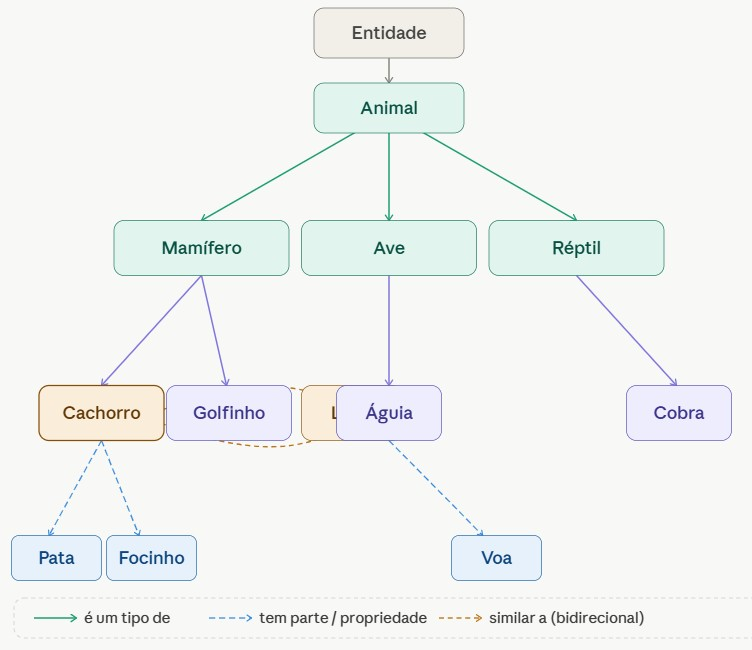

---

### 1.4 — O que é o WordNet?

O **WordNet** é um banco de dados léxico da língua inglesa, criado pela Universidade de Princeton.  
Ele organiza as palavras em grupos de sinônimos chamados **synsets** (conjuntos de sinônimos).

- **Wordnet - synsets** --> mostra os 3 synsets de dog com nome, definição e sinônimos

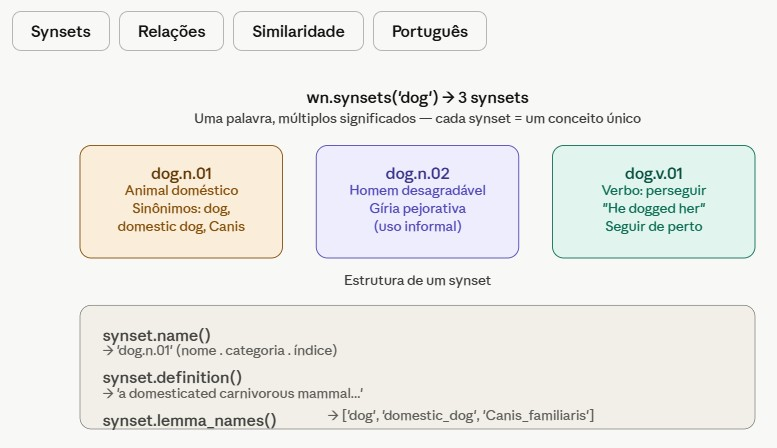

- **Wordnet - Relações** --> diagrama com hypernym, hyponym e meronym em cores e métodos NLTK

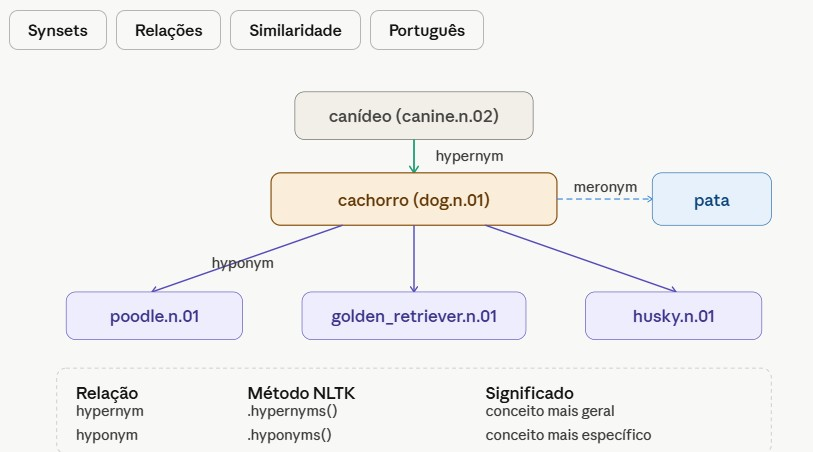

- **Wordnet - Similaridade** --> barras horizontais comparando path_similarity entre pares

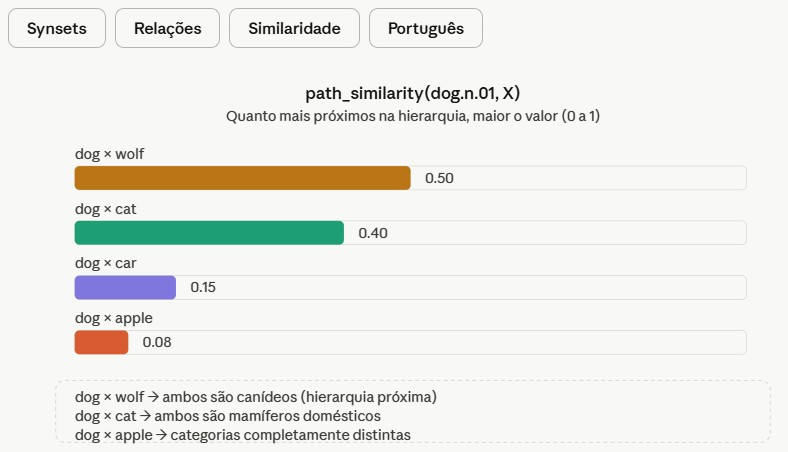

- **Wordnet - Português** --> tradução de synsets EN → PT com *omw-1.4*

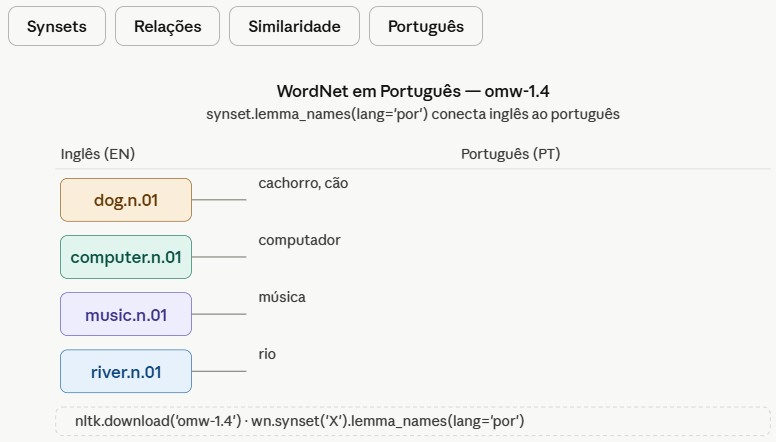

Cada **synset** representa um **conceito único** e possui:
- Uma **definição** (gloss)
- **Exemplos** de uso
- **Relações** com outros synsets

**Principais relações no WordNet:**

| Relação | Significado | Exemplo |
|---|---|---|
| **hypernym** | "é um tipo de" (mais geral) | cachorro → animal |
| **hyponym** | "é um tipo de" (mais específico) | animal → cachorro |
| **meronym** | "faz parte de" | pata → cachorro |
| **holonym** | "contém" | cachorro → pata |
| **synonym** | mesmo significado | cão ↔ cachorro |
| **antonym** | significado oposto | quente ↔ frio |

---

### 1.5 — O que é o BabelNet?

O **BabelNet** é uma evolução multilíngue do WordNet.  
Ele combina WordNet com a Wikipedia e outros recursos, cobrindo **500+ idiomas**,  
incluindo o **Português**.


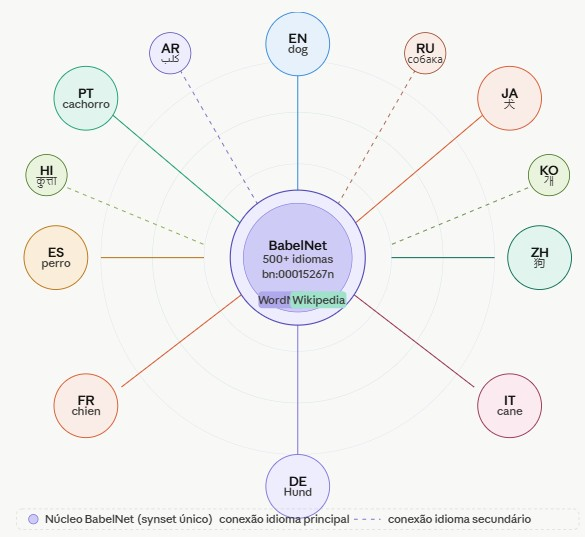


Enquanto o WordNet foca no inglês, o BabelNet conecta conceitos entre idiomas:
```
  'dog' (EN) ←──── conceito ────→ 'cachorro' (PT)
                      │
                  'Hund' (DE)
                  'chien' (FR)
```

> 💡 Nesta aula usaremos o **WordNet via NLTK** (disponível localmente).  
> O BabelNet requer API key, então exploraremos seu conceito e interface web.

---

# Similaridade Semântica

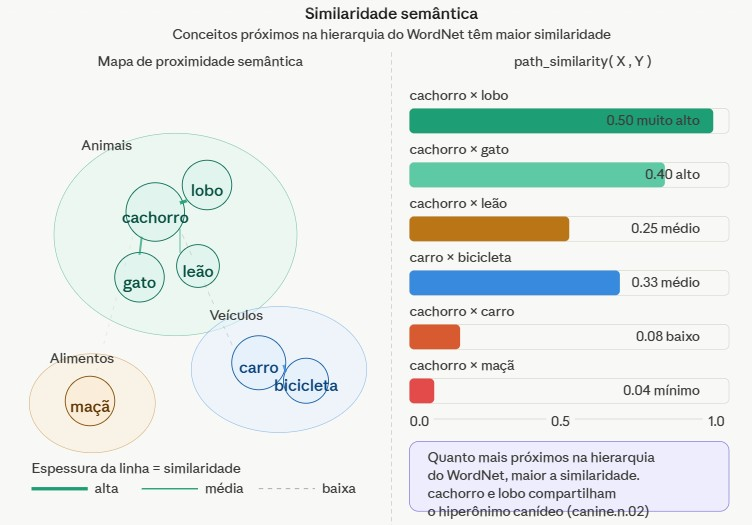

# Ambiguidade lexical - 01

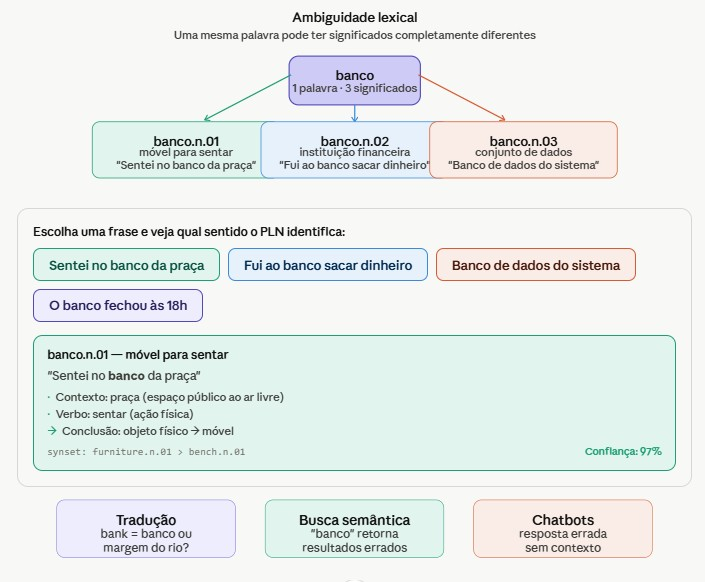

# Ambiguidade Lexical - 02

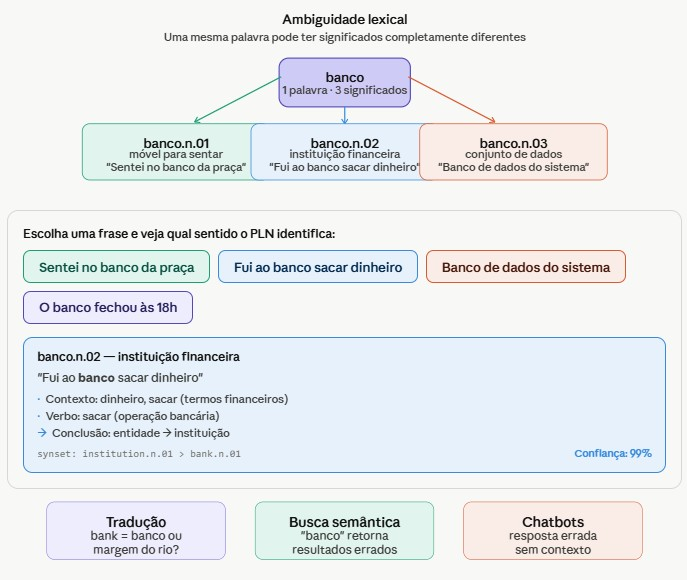

# Ambiguidade Lexical - 03

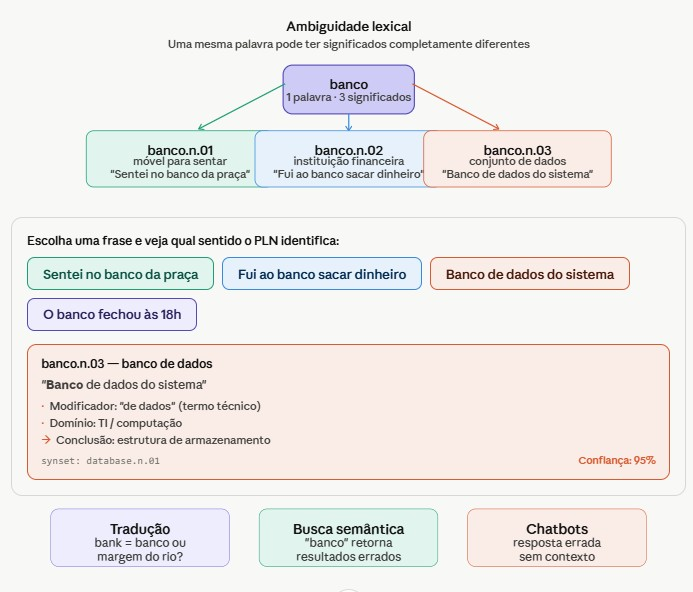

# Ambiguidade Lexical - 04

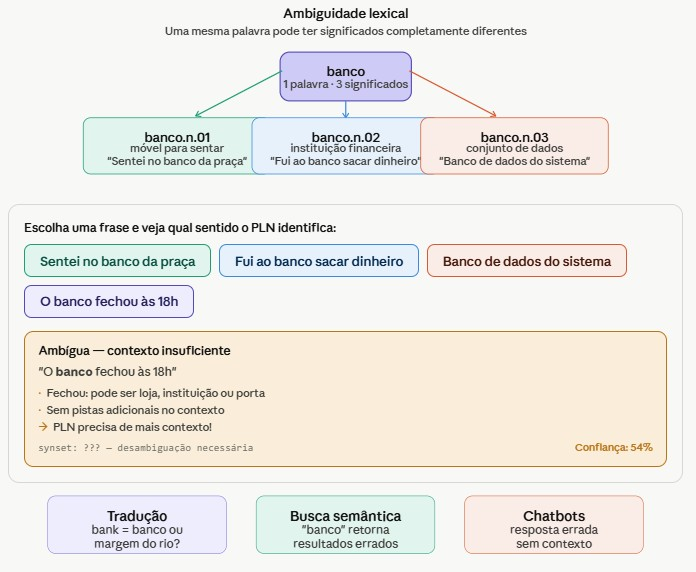

## 🛠️ Parte Prática

### Configuração Inicial

Primeiro, vamos importar as bibliotecas e baixar os recursos necessários.

In [ ]:
# ─────────────────────────────────────────────────────────────
# IMPORTAÇÕES
# nltk  → biblioteca de PLN com acesso ao WordNet
# networkx → biblioteca para criar e visualizar grafos
# matplotlib → biblioteca para plotar gráficos e figuras
# ─────────────────────────────────────────────────────────────

import nltk
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Baixar os recursos do WordNet (só precisa rodar uma vez)
nltk.download('wordnet')    # Base de dados do WordNet
nltk.download('omw-1.4')    # Suporte a múltiplos idiomas (inclui Português)
nltk.download('punkt')      # Tokenizador de sentenças

# Importar o WordNet do NLTK
from nltk.corpus import wordnet as wn

print('✅ Bibliotecas importadas com sucesso!')

---
### 📖 Exemplo 1 — Explorando Synsets no WordNet

Um **synset** é um conjunto de palavras com o mesmo significado.  
Vamos explorar os synsets da palavra **'dog'** (cachorro em inglês).

In [ ]:
# ─────────────────────────────────────────────────────────────
# wn.synsets('palavra') → retorna todos os synsets de uma palavra
# Cada synset representa um sentido/significado diferente
# ─────────────────────────────────────────────────────────────

# Buscar todos os synsets da palavra 'dog'
synsets_dog = wn.synsets('dog')

print(f'A palavra "dog" possui {len(synsets_dog)} synset(s) no WordNet:\n')

# Percorrer cada synset e exibir suas informações
for i, synset in enumerate(synsets_dog):
    print(f'Synset {i+1}: {synset.name()}')
    print(f'  Definição : {synset.definition()}')
    
    # Alguns synsets têm exemplos de uso
    if synset.examples():
        print(f'  Exemplos  : {synset.examples()}')
    
    # Listar os lemas (palavras/sinônimos) do synset
    lemas = [lema.name() for lema in synset.lemmas()]
    print(f'  Sinônimos : {lemas}')
    print()

---
### 📖 Exemplo 2 — Explorando Relações entre Palavras

Agora vamos explorar as relações hierárquicas de um synset específico.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Vamos trabalhar com o primeiro synset de 'dog'
# que representa o animal doméstico
# ─────────────────────────────────────────────────────────────

# Selecionar o synset 'dog.n.01' (cachorro como substantivo)
cachorro = wn.synset('dog.n.01')

print(f'Synset escolhido: {cachorro.name()}')
print(f'Definição: {cachorro.definition()}')
print()

# ── Hypernyms: conceitos mais GERAIS ("é um tipo de")
# Exemplo: cachorro é um tipo de... canídeo, mamífero, animal...
hypernyms = cachorro.hypernyms()
print('📈 Hypernyms (conceitos mais gerais — "cachorro É UM TIPO DE"):')
for h in hypernyms:
    print(f'   → {h.name()} : {h.definition()}')

print()

# ── Hyponyms: conceitos mais ESPECÍFICOS ("tipos de cachorro")
# Exemplo: tipos de cachorro → golden retriever, poodle...
hyponyms = cachorro.hyponyms()
print(f'📉 Hyponyms (conceitos mais específicos — "tipos de cachorro"): {len(hyponyms)} encontrados')
for h in hyponyms[:5]:  # Mostrar apenas os 5 primeiros
    print(f'   → {h.name()} : {h.definition()}')

print()

# ── Meronyms: partes DO cachorro
# Exemplo: pata, rabo, focinho fazem PARTE do cachorro
meronyms = cachorro.part_meronyms()
print('🔩 Meronyms (partes do cachorro):')
for m in meronyms:
    print(f'   → {m.name()} : {m.definition()}')

---
### 📖 Exemplo 3 — Hierarquia Completa (do conceito ao topo)

O WordNet organiza os conceitos em uma hierarquia que vai até **'entity'** (entidade), o conceito mais geral de tudo.

In [ ]:
# ─────────────────────────────────────────────────────────────
# hypernym_paths() → retorna o caminho completo desde o synset
# até o topo da hierarquia (entity)
# ─────────────────────────────────────────────────────────────

cachorro = wn.synset('dog.n.01')

# Obter o caminho hierárquico completo
caminhos = cachorro.hypernym_paths()

print('🌳 Hierarquia completa de "dog" (do específico ao geral):\n')

# O primeiro caminho é o principal
caminho_principal = caminhos[0]

# Mostrar o caminho de forma visual com indentação
for nivel, synset in enumerate(caminho_principal):
    # Cada nível mais profundo fica mais indentado
    indentacao = '  ' * nivel
    seta = '└─ ' if nivel > 0 else ''
    print(f'{indentacao}{seta}{synset.name()}')

---
### 📖 Exemplo 4 — Similaridade entre Palavras

O WordNet permite calcular a **similaridade semântica** entre duas palavras.  
Quanto mais próximas na hierarquia, mais similar o valor (de 0 a 1).

In [ ]:
# ─────────────────────────────────────────────────────────────
# path_similarity() → calcula similaridade entre dois synsets
# baseado na distância entre eles na hierarquia do WordNet
# Resultado: valor entre 0 (nenhuma relação) e 1 (idênticos)
# ─────────────────────────────────────────────────────────────

# Definir os synsets que queremos comparar
cachorro = wn.synset('dog.n.01')    # cachorro
gato     = wn.synset('cat.n.01')    # gato
lobo     = wn.synset('wolf.n.01')   # lobo
carro    = wn.synset('car.n.01')    # carro
fruta    = wn.synset('fruit.n.01')  # fruta

# Calcular similaridade entre cada par
comparacoes = [
    (cachorro, gato,  'dog × cat'),
    (cachorro, lobo,  'dog × wolf'),
    (cachorro, carro, 'dog × car'),
    (cachorro, fruta, 'dog × fruit'),
]

print('📊 Similaridade semântica (escala de 0 a 1):\n')
print(f'{"Par":<20} {"Similaridade":<15} {"Interpretação"}')
print('-' * 55)

for s1, s2, nome in comparacoes:
    sim = s1.path_similarity(s2)  # Calcular similaridade
    sim_str = f'{sim:.4f}' if sim else 'N/A'
    
    # Interpretar o resultado
    if sim and sim > 0.3:
        interpretacao = '🟢 Muito similar'
    elif sim and sim > 0.1:
        interpretacao = '🟡 Pouco similar'
    else:
        interpretacao = '🔴 Muito diferente'
    
    print(f'{nome:<20} {sim_str:<15} {interpretacao}')

---
### 📖 Exemplo 5 — WordNet em Português

Com o pacote `omw-1.4`, podemos buscar palavras e traduções em **Português**!

In [ ]:
# ─────────────────────────────────────────────────────────────
# lemmas(lang='por') → retorna os lemas (formas da palavra)
# no idioma especificado. 'por' = Português
# ─────────────────────────────────────────────────────────────

# Buscar synsets da palavra 'cachorro' em português
print('🇧🇷 Buscando a palavra "cachorro" em Português:\n')
synsets_pt = wn.synsets('cachorro', lang='por')

for syn in synsets_pt:
    print(f'Synset: {syn.name()}')
    print(f'Definição (EN): {syn.definition()}')
    
    # Buscar os lemas em português
    lemas_pt = syn.lemma_names(lang='por')
    print(f'Palavras em PT: {lemas_pt}')
    print()

print('─' * 50)
print()

# Traduzir: dado um synset em inglês, buscar o equivalente em PT
print('🔄 Tradução: synsets em inglês → equivalente em Português\n')

palavras_en = ['computer', 'music', 'love', 'river']

for palavra in palavras_en:
    synsets = wn.synsets(palavra)
    if synsets:
        primeiro = synsets[0]  # Pegar o significado mais comum
        lemas_pt = primeiro.lemma_names(lang='por')
        print(f'  {palavra:<12} → {lemas_pt}')

---
### 📖 Exemplo 6 — Visualizando um Grafo de Conhecimento

Agora vamos construir e visualizar um **grafo de conhecimento** com NetworkX,  
mostrando as relações hierárquicas de um conjunto de animais.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Vamos construir um grafo de conhecimento mostrando a hierarquia
# de animais usando o WordNet e visualizá-lo com NetworkX
# ─────────────────────────────────────────────────────────────

def construir_grafo_hierarquia(synset, profundidade_max=3):
    """
    Constrói um grafo de hierarquia a partir de um synset.
    
    Parâmetros:
        synset         : o synset raiz (ponto de partida)
        profundidade_max: quantos níveis subir na hierarquia
    
    Retorna:
        G : grafo direcionado com as relações
    """
    # Criar um grafo DIRECIONADO (as arestas têm direção)
    G = nx.DiGraph()
    
    # Função recursiva para percorrer a hierarquia
    def adicionar_nos(syn, profundidade):
        # Parar quando atingir a profundidade máxima
        if profundidade == 0:
            return
        
        # Nome simplificado do synset (só a palavra, sem o sufixo)
        nome_atual = syn.name().split('.')[0]
        
        # Adicionar hyponyms (conceitos mais específicos)
        for hypo in syn.hyponyms()[:4]:  # Limitar a 4 por nó
            nome_filho = hypo.name().split('.')[0]
            G.add_edge(nome_atual, nome_filho)  # Aresta: pai → filho
            adicionar_nos(hypo, profundidade - 1)  # Recursão
    
    # Adicionar o nó raiz e construir o grafo
    nome_raiz = synset.name().split('.')[0]
    G.add_node(nome_raiz)
    adicionar_nos(synset, profundidade_max)
    
    return G


# ── Construir o grafo a partir de 'carnivore' (carnívoro)
raiz = wn.synset('canine.n.02')  # canídeos: inclui cão, lobo, raposa...
G = construir_grafo_hierarquia(raiz, profundidade_max=2)

# ── Configurar a figura
plt.figure(figsize=(14, 8))
plt.title('🐾 Grafo de Conhecimento — Família dos Canídeos (WordNet)',
          fontsize=14, fontweight='bold', pad=20)

# Layout hierárquico (de cima para baixo)
pos = nx.spring_layout(G, seed=42, k=2.5)

# ── Colorir nós por nível de profundidade
nos = list(G.nodes())
raiz_nome = raiz.name().split('.')[0]

# Definir cores: raiz em azul, filhos em verde, netos em laranja
cores = []
for no in nos:
    if no == raiz_nome:
        cores.append('#2196F3')   # Azul — nó raiz
    elif G.in_degree(no) == 1 and G.out_degree(no) > 0:
        cores.append('#4CAF50')   # Verde — nível intermediário
    else:
        cores.append('#FF9800')   # Laranja — folhas

# Desenhar o grafo
nx.draw_networkx_nodes(G, pos, node_color=cores, node_size=1500, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20,
                       edge_color='#555555', width=1.5,
                       arrowstyle='->', connectionstyle='arc3,rad=0.1')

# Legenda
legenda = [
    mpatches.Patch(color='#2196F3', label='Conceito raiz'),
    mpatches.Patch(color='#4CAF50', label='Nível intermediário'),
    mpatches.Patch(color='#FF9800', label='Conceito específico'),
]
plt.legend(handles=legenda, loc='upper left', fontsize=9)

plt.axis('off')  # Remover os eixos
plt.tight_layout()
plt.show()

print(f'\n📊 Grafo criado com {G.number_of_nodes()} nós e {G.number_of_edges()} arestas')

---
### 📖 Exemplo 7 — BabelNet: Recurso Multilíngue

O **BabelNet** não está disponível para instalação local gratuita,  
mas podemos explorar sua **API web** e entender sua estrutura.

In [ ]:
# ─────────────────────────────────────────────────────────────
# BabelNet via API REST
# Para usar o BabelNet completo, é necessário:
#   1. Criar uma conta em: https://babelnet.org/
#   2. Obter uma API key gratuita
#   3. Usar a API conforme exemplificado abaixo
# ─────────────────────────────────────────────────────────────

# Simulação da estrutura do BabelNet para fins didáticos
# (a estrutura real retornada pela API é similar a este dicionário)

babelnet_exemplo = {
    'id': 'bn:00015267n',         # ID único do conceito no BabelNet
    'concept': 'cachorro / dog',   # Conceito representado
    'categorias': [
        'Mamíferos', 'Animais domésticos', 'Canídeos'
    ],
    'traducoes': {
        'PT': ['cachorro', 'cão'],      # Português
        'EN': ['dog', 'domestic dog'],  # Inglês
        'ES': ['perro'],                # Espanhol
        'FR': ['chien'],                # Francês
        'DE': ['Hund', 'Haushund'],     # Alemão
        'IT': ['cane'],                 # Italiano
        'ZH': ['狗', '犬'],             # Chinês
        'JA': ['犬', 'イヌ'],           # Japonês
    },
    'relacoes': [
        {'tipo': 'is-a',       'destino': 'bn:00050933n', 'label': 'canídeo'},
        {'tipo': 'related-to', 'destino': 'bn:00014308n', 'label': 'gato'},
        {'tipo': 'related-to', 'destino': 'bn:00082495n', 'label': 'lobo'},
    ]
}

# Exibir a estrutura de forma organizada
print('🌐 Estrutura de um conceito no BabelNet')
print('=' * 50)
print(f'ID       : {babelnet_exemplo["id"]}')
print(f'Conceito : {babelnet_exemplo["concept"]}')
print(f'Categorias: {", ".join(babelnet_exemplo["categorias"])}')
print()

print('🌍 Traduções em 500+ idiomas (amostra):')
for idioma, palavras in babelnet_exemplo['traducoes'].items():
    print(f'   [{idioma}] → {", ".join(palavras)}')

print()
print('🔗 Relações com outros conceitos:')
for rel in babelnet_exemplo['relacoes']:
    print(f'   {rel["tipo"]:<12} → {rel["label"]} ({rel["destino"]})')

print()
print('💡 Para usar a API real: https://babelnet.org/guide')

---
## ✏️ Exercícios

Agora é a sua vez! Resolva os exercícios abaixo nas células indicadas.

> 💡 **Dica:** Use os exemplos anteriores como referência.

### Exercício 1
Escolha uma palavra em inglês de sua preferência e:
- Liste todos os **synsets** dessa palavra
- Para cada synset, mostre sua **definição** e **sinônimos**

In [ ]:
# ── Exercício 1 — Seu código aqui ──

# Dica: use wn.synsets('sua_palavra')
# e para cada synset: synset.definition() e synset.lemmas()


### Exercício 2
Usando o synset `'tree.n.01'` (árvore):
- Liste seus **hypernyms** (conceitos mais gerais)
- Liste seus **hyponyms** (tipos de árvore) — mostre apenas os 5 primeiros
- Liste seus **meronyms** (partes da árvore)

In [ ]:
# ── Exercício 2 — Seu código aqui ──

# Dica: arvore = wn.synset('tree.n.01')
# e use: .hypernyms(), .hyponyms(), .part_meronyms()


### Exercício 3
Compare a similaridade semântica entre os seguintes pares de palavras e interprete os resultados:
- `'car.n.01'` e `'bicycle.n.01'`
- `'car.n.01'` e `'airplane.n.01'`
- `'car.n.01'` e `'apple.n.01'`

Qual par é mais similar? Isso faz sentido para você? Explique.

In [ ]:
# ── Exercício 3 — Seu código aqui ──

# Dica: use .path_similarity() para comparar os synsets
# Lembre: valores próximos de 1 = muito similar

# Escreva sua interpretação aqui como comentário:
# R:

### Exercício 4 — Desafio
Construa um **grafo de conhecimento** para um tema de sua escolha  
(ex.: frutas, veículos, instrumentos musicais) com pelo menos:
- 1 nó raiz
- 2 níveis de hierarquia
- Cores diferentes para cada nível

In [ ]:
# ── Exercício 4 — Seu código aqui ──

# Dica: use a função construir_grafo_hierarquia() já criada
# Exemplos de synsets para usar como raiz:
#   wn.synset('fruit.n.01')        → frutas
#   wn.synset('vehicle.n.01')      → veículos
#   wn.synset('musical_instrument.n.01') → instrumentos


---
## 📝 Resumo da Aula

| Conceito | O que é | Para que serve |
|---|---|---|
| **Ontologia** | Estrutura formal de conceitos e relações | Ensinar o computador a entender significados |
| **Grafo de Conhecimento** | Representação visual de ontologias | Visualizar e navegar relações entre conceitos |
| **Synset** | Conjunto de sinônimos no WordNet | Representar um único sentido/conceito |
| **Hypernym** | Conceito mais geral | Hierarquia "é um tipo de" para cima |
| **Hyponym** | Conceito mais específico | Hierarquia "é um tipo de" para baixo |
| **Meronym** | Parte de um conceito | Relação "faz parte de" |
| **WordNet** | Banco léxico do inglês (Princeton) | Fonte de relações semânticas |
| **BabelNet** | WordNet multilíngue (500+ idiomas) | PLN em múltiplos idiomas |

---

## 🔜 Próxima Aula

**Aula 2 — Tecnologias e Ferramentas**  
Vamos conhecer as principais ferramentas de PLN na prática:  
**spaCy**, **NLTK** (pipeline completo), **Hugging Face**, **OpenCV** e **TensorFlow**.